# Trabajo Final — Sistema Multiagente
## Evacuación de un edificio durante un incendio

**Integrantes:** Andre Chipana, Andy Muzo, Mauricio Vera y Jhair Quispe

## 1. El problema

Un incendio se declara en la cocina de un edificio de oficinas de dos plantas conceptuales (una sola planta física con 4 salas, un pasillo central y dos atrios abiertos, ver `simulation/floorplan.py`). Cada persona dentro del edificio es un **agente autónomo** que debe decidir, en tiempo real y con información local, cómo llegar a una salida antes de que el fuego o el humo se lo impidan.

No hay un controlador central: cada persona percibe su entorno inmediato (vecinos, paredes, fuego, humo) y actúa en consecuencia. El comportamiento colectivo de evacuación (cuellos de botella, aglomeración en las puertas, pánico que se contagia) **emerge** de estas decisiones individuales — es exactamente el tipo de fenómeno que los sistemas multiagente están hechos para modelar, y no se puede resolver con una única función de optimización global sin perder ese realismo.

Referencia académica del modelo de fuerzas usado: Helbing, D., Farkas, I., & Vicsek, T. (2000). *Simulating dynamical features of escape panic*. Nature, 407(6803), 487-490.

## 2. Reglas del modelo

### Entorno
- El edificio (30m × 18m) se representa como una grilla de celdas de 0.4m (`simulation/floorplan.py`). Las paredes bloquean celdas; el resto queda libre.
- Esa **misma grilla** se usa para el pathfinding (A\*) y para la propagación del fuego: el fuego nunca "atraviesa" una pared porque, por construcción, las celdas de pared no son transitables ni combustibles. Solo se propaga por los huecos de las puertas.
- Hay 2 salidas, una a cada extremo del pasillo central.

### Agente Fuego (`simulation/fire.py`)
- Cada celda libre tiene combustible. Una celda ardiendo contagia a sus vecinas libres con una probabilidad proporcional a su intensidad.
- La intensidad crece mientras hay combustible; al agotarse, decae (brasas) hasta apagarse.
- El **humo** se difunde de forma independiente (llega más lejos y más rápido que el fuego) y es lo primero que reduce la "visibilidad" psicológica de las personas cercanas.

### Agente Persona (`simulation/agents.py`) — modelo de fuerzas sociales de Helbing
Cada persona se mueve por la suma de 4 fuerzas (no por una regla de "ir al punto X"):
1. **Impulso**: fuerza hacia el siguiente punto de su ruta A\* a la salida más cercana (la ruta se recalcula si el fuego la bloquea).
2. **Repulsión social**: de otras personas, más una fuerza de contacto físico real si llegan a tocarse (empuje/atropello en cuellos de botella).
3. **Repulsión de paredes**: para no atravesarlas ni pegarse a ellas.
4. **Repulsión del fuego**: un gradiente que aleja a la persona de las celdas más calientes cercanas.

**Pánico y manada:** el pánico de cada persona sube con la exposición al fuego/humo y con el hacinamiento, y decae con el tiempo si está a salvo. A mayor pánico: (a) camina más rápido, y (b) si además hay humo denso, deja de seguir su ruta óptima y en su lugar tiende a copiar el rumbo promedio de las personas a su alrededor — el comportamiento de "manada" documentado en la literatura de evacuación.

**Estados:** `normal` → `panic` (pánico alto) → `evacuated` (llegó a una salida) | `trapped` (A\* no encuentra ruta libre de fuego) | `casualty` (expuesta a intensidad letal más de 1.5s).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from simulation.world import World
from simulation import floorplan as fp
from simulation.agents import (
    STATUS_NORMAL, STATUS_PANIC, STATUS_TRAPPED, STATUS_EVACUATED, STATUS_CASUALTY,
)

STATUS_COLOR = {
    STATUS_NORMAL: "#4ea8ff",
    STATUS_PANIC: "#ffb454",
    STATUS_TRAPPED: "#b23bff",
    STATUS_EVACUATED: "#33d17a",
    STATUS_CASUALTY: "#55596b",
}

## 3. Simulación del entorno (demo standalone en el notebook)

Se crea el edificio con 42 personas repartidas en las 4 salas. El incendio se enciende en la cocina en el frame 15. La animación de abajo corre el mismo motor (`simulation/`) que usa la versión web 3D — aquí solo cambia cómo se dibuja (matplotlib en vez de Three.js).

In [2]:
random.seed(7)
DT = 0.08
SPARK_AT_FRAME = 15
FRAMES = 260

world = World(n_agents=42)
history = []

fig, ax = plt.subplots(figsize=(9, 5.6))
fig.patch.set_facecolor("#05070c")


def draw_static(ax):
    ax.set_facecolor("#0d1119")
    for name, data in fp.ROOMS.items():
        x0, y0, x1, y1 = data["bounds"]
        color = "#241414" if name == "cocina" else "#141b26"
        ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                         facecolor=color, edgecolor="none", zorder=0))
    for (x1, y1, x2, y2) in fp.WALLS:
        ax.plot([x1, x2], [y1, y2], color="#cfd6e6", lw=2.4, zorder=2)
    for (ex, ey) in fp.EXITS:
        ax.add_patch(mpatches.Circle((ex, ey), 0.5, facecolor="#33d17a",
                                      edgecolor="none", alpha=0.85, zorder=2))


def init():
    ax.clear()
    ax.set_xlim(0, fp.WIDTH); ax.set_ylim(0, fp.HEIGHT)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    draw_static(ax)
    return []


def update(frame):
    if frame == SPARK_AT_FRAME:
        world.spark()
    world.step(DT)
    stats = world.stats()
    history.append({"t": world.time, **stats})

    ax.clear()
    ax.set_xlim(0, fp.WIDTH); ax.set_ylim(0, fp.HEIGHT)
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    draw_static(ax)

    for i, row in enumerate(world.fire.intensity):
        for j, inten in enumerate(row):
            if inten > 0.02:
                cx, cy = fp.cell_center(i, j)
                ax.add_patch(mpatches.Rectangle(
                    (cx - fp.CELL / 2, cy - fp.CELL / 2), fp.CELL, fp.CELL,
                    facecolor="#ff5a1f", alpha=min(1.0, inten), edgecolor="none", zorder=3))
    for i, row in enumerate(world.fire.smoke):
        for j, s in enumerate(row):
            if s > 0.05:
                cx, cy = fp.cell_center(i, j)
                ax.add_patch(mpatches.Rectangle(
                    (cx - fp.CELL / 2, cy - fp.CELL / 2), fp.CELL, fp.CELL,
                    facecolor="#9099ad", alpha=min(0.55, s * 0.5), edgecolor="none", zorder=3))

    for p in world.people:
        ax.add_patch(mpatches.Circle((p.x, p.y), 0.22, facecolor=STATUS_COLOR[p.status],
                                      edgecolor="#05070c", lw=0.4, zorder=4))

    ax.set_title(
        f"t={world.time:5.1f}s   evacuados={stats['evacuated']}/{stats['total']}   "
        f"atrapados={stats['trapped']}   víctimas={stats['casualties']}",
        color="#e8ecf4", fontsize=10)
    return []


anim = FuncAnimation(fig, update, frames=FRAMES, init_func=init, blit=False, interval=50)
plt.close()
HTML(anim.to_jshtml())

## 4. Métricas de la corrida

`history` se fue llenando durante la animación anterior con el estado agregado en cada tick. Con eso graficamos la curva de evacuación.

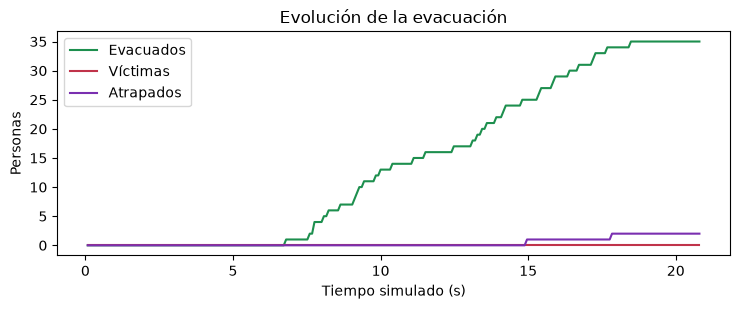

Resultado final: {'evacuated': 35, 'casualties': 0, 'trapped': 2, 'active': 5, 'total': 40, 'elapsed': 20.8, 'fire_ignited': True}


In [3]:
ts = [h["t"] for h in history]
plt.figure(figsize=(7.5, 3.2))
plt.plot(ts, [h["evacuated"] for h in history], label="Evacuados", color="#1d8f4e")
plt.plot(ts, [h["casualties"] for h in history], label="V\u00edctimas", color="#c0334a")
plt.plot(ts, [h["trapped"] for h in history], label="Atrapados", color="#7a2fb0")
plt.xlabel("Tiempo simulado (s)")
plt.ylabel("Personas")
plt.title("Evoluci\u00f3n de la evacuaci\u00f3n")
plt.legend()
plt.tight_layout()
plt.show()

print("Resultado final:", world.stats())